## PCA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler,OrdinalEncoder,LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

In [2]:
df=pd.read_csv('wine.csv')

In [3]:
df.shape

(178, 14)

In [4]:
df.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [6]:
df.describe()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [7]:
### missing values
df.isnull().sum()

Type               0
Alcohol            0
Malic              0
Ash                0
Alcalinity         0
Magnesium          0
Phenols            0
Flavanoids         0
Nonflavanoids      0
Proanthocyanins    0
Color              0
Hue                0
Dilution           0
Proline            0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

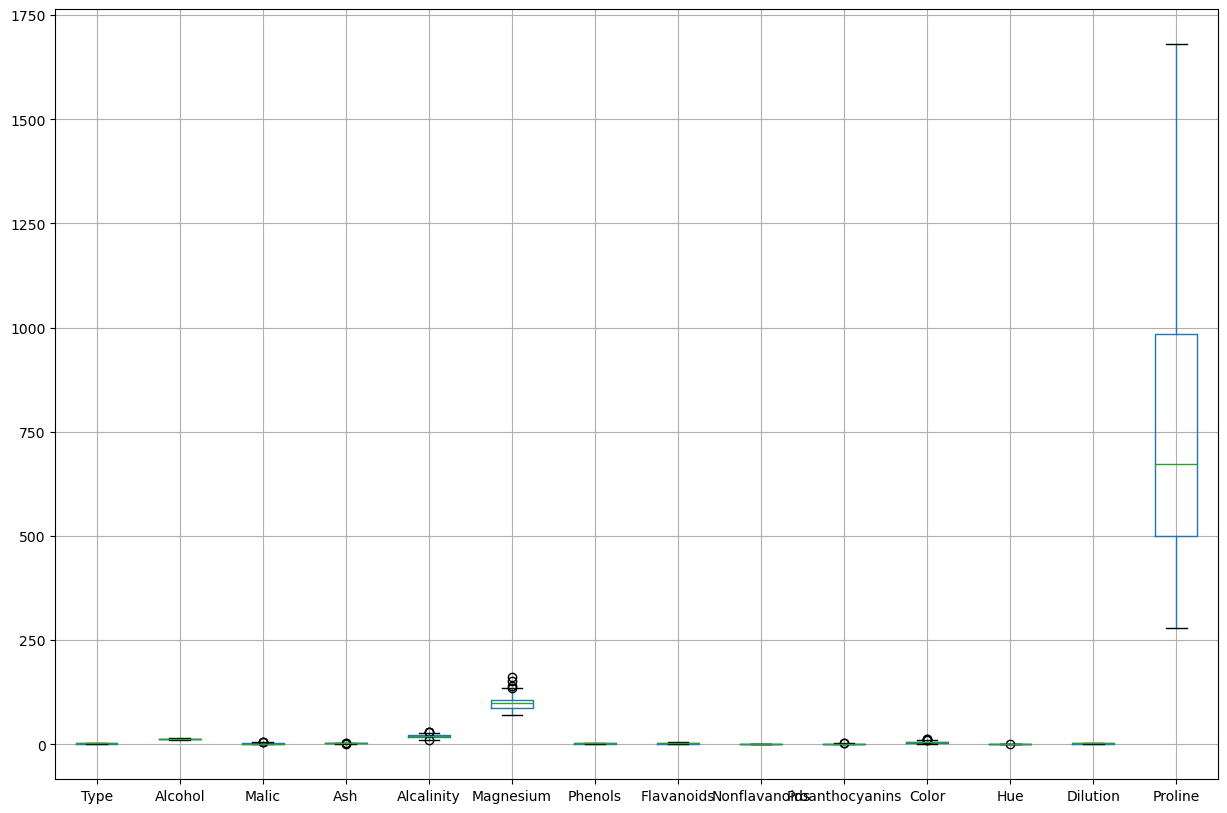

In [11]:
plt.figure(figsize=(15,10))
df.boxplot()
plt.show()

In [12]:
### outlier capping
def outlier_capping(df,column):
    Q1= df[column].quantile(0.25)
    Q3= df[column].quantile(0.75)
    IQR= Q3-Q1
    lower_extreme= Q1-1.5*IQR
    upper_extreme= Q3+1.5*IQR
    df[column]= df[column].apply(lambda x: lower_extreme if x<lower_extreme else upper_extreme if x>upper_extreme else x)
for col in df.select_dtypes(['int','float']).columns:
    outlier_capping(df,col)

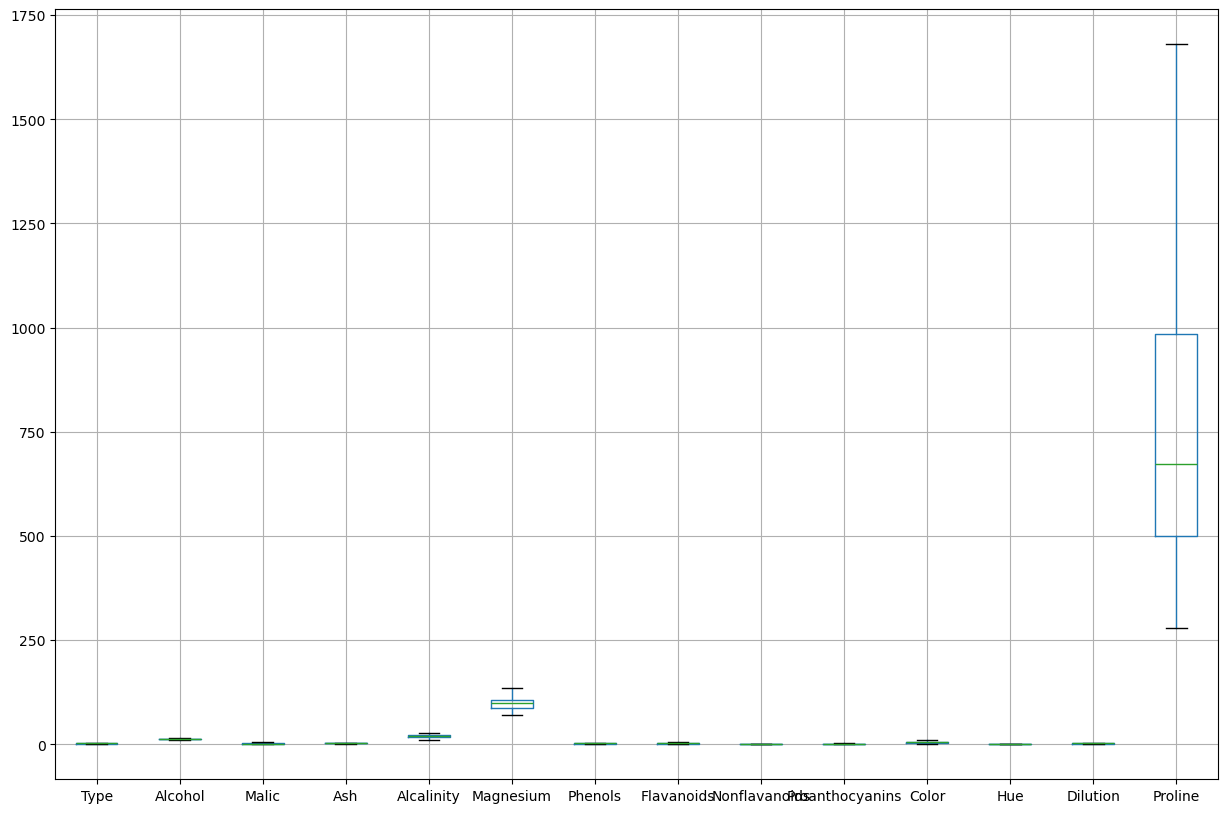

In [13]:
plt.figure(figsize=(15,10))
df.boxplot()
plt.show()

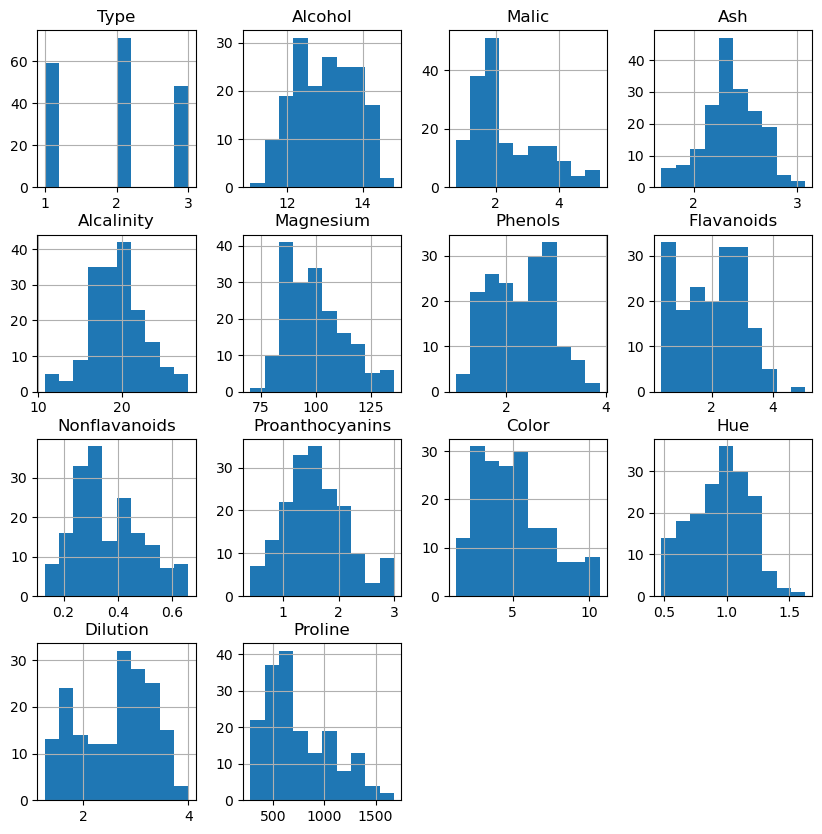

In [16]:
# Histogram
df.hist(figsize=(10,10))
plt.show()

In [17]:
### correlation
corr=df.corr()
corr

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
Type,1.000000,-0.328222,0.440422,-0.047680,0.525608,-0.224264,-0.719163,-0.847498,0.489109,-0.512528,0.260260,-0.621549,-0.788230,-0.633717
Alcohol,-0.328222,1.000000,0.094756,0.220174,-0.312191,0.302173,0.289101,0.236815,-0.155929,0.153171,0.549107,-0.067156,0.072343,0.643720
Malic,0.440422,0.094756,1.000000,0.166614,0.295882,-0.039329,-0.339050,-0.414875,0.294203,-0.234575,0.264897,-0.566409,-0.372582,-0.191173
Ash,-0.047680,0.220174,0.166614,1.000000,0.427713,0.322510,0.124436,0.097562,0.183666,0.006080,0.256799,-0.075904,-0.011214,0.229676
Alcalinity,0.525608,-0.312191,0.295882,0.427713,1.000000,-0.098030,-0.333046,-0.363405,0.369276,-0.208794,0.009748,-0.286664,-0.287032,-0.448700
Magnesium,-0.224264,0.302173,-0.039329,0.322510,-0.098030,1.000000,0.227035,0.209431,-0.255674,0.201428,0.240505,0.040007,0.064019,0.411557
Phenols,-0.719163,0.289101,-0.339050,0.124436,-0.333046,0.227035,1.000000,0.864564,-0.449935,0.618771,-0.062101,0.435952,0.699949,0.498115
Flavanoids,-0.847498,0.236815,-0.414875,0.097562,-0.363405,0.209431,0.864564,1.000000,-0.537900,0.665384,-0.169807,0.546718,0.787194,0.494193
Nonflavanoids,0.489109,-0.155929,0.294203,0.183666,0.369276,-0.255674,-0.449935,-0.537900,1.000000,-0.368455,0.131596,-0.266995,-0.503270,-0.311385
Proanthocyanins,-0.512528,0.153171,-0.234575,0.006080,-0.208794,0.201428,0.618771,0.665384,-0.368455,1.000000,-0.032693,0.306289,0.530565,0.340562


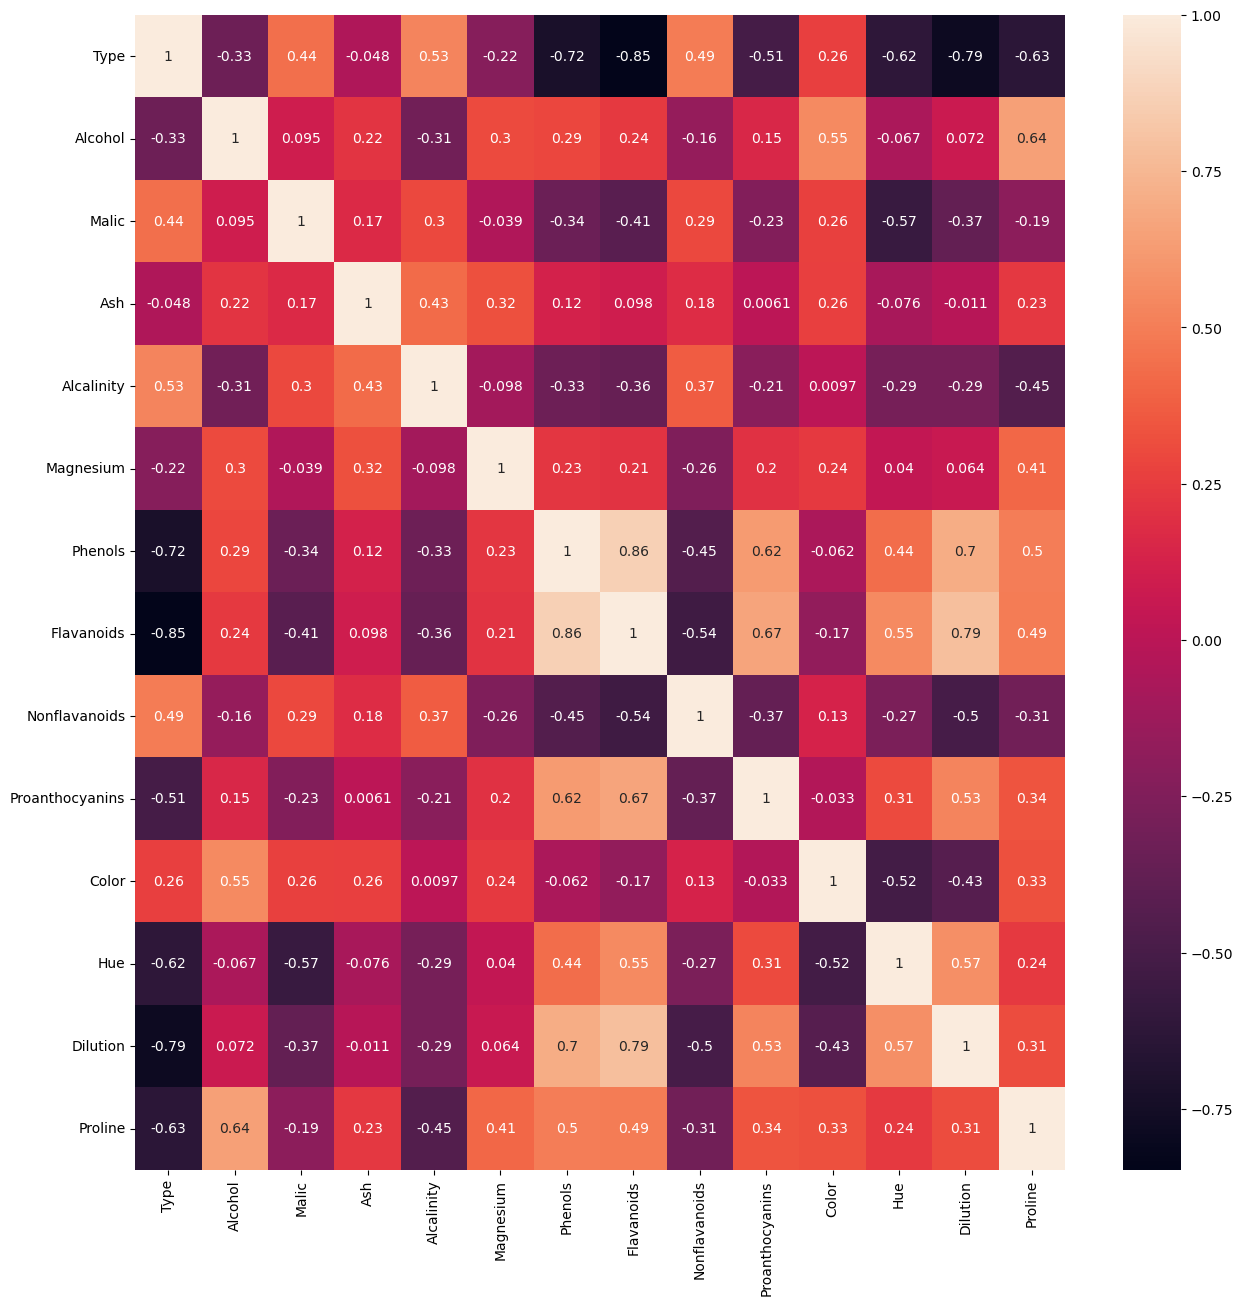

In [23]:
# Heatmap
plt.figure(figsize=(15,15))
sns.heatmap(corr,annot=True)
plt.show()

In [24]:
target=df[['Type']]
features=df.drop(columns=['Type'])
features.columns

Index(['Alcohol', 'Malic', 'Ash', 'Alcalinity', 'Magnesium', 'Phenols',
       'Flavanoids', 'Nonflavanoids', 'Proanthocyanins', 'Color', 'Hue',
       'Dilution', 'Proline'],
      dtype='object')

In [25]:
### Standardize the features
std_scaler=StandardScaler()
features[['Alcohol', 'Malic', 'Ash', 'Alcalinity', 'Magnesium', 'Phenols',
       'Flavanoids', 'Nonflavanoids', 'Proanthocyanins', 'Color', 'Hue',
       'Dilution', 'Proline']]=std_scaler.fit_transform(features[['Alcohol', 'Malic', 'Ash', 'Alcalinity', 'Magnesium', 'Phenols',
       'Flavanoids', 'Nonflavanoids', 'Proanthocyanins', 'Color', 'Hue',
       'Dilution', 'Proline']])

In [26]:
features.head()

,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1.518613,-0.565534,0.240640,-1.182882,2.057111,0.808997,1.034819,-0.659563,1.264740,0.266954,0.366610,1.847920,1.013009
1,0.246290,-0.501728,-0.862176,-2.524956,0.038639,0.568648,0.733629,-0.820719,-0.549904,-0.291923,0.410768,1.113449,0.965242
2,0.196879,0.026948,1.153315,-0.267832,0.113397,0.808997,1.215533,-0.498407,2.199012,0.284696,0.322451,0.788587,1.395148
3,1.691550,-0.346771,0.506837,-0.816862,1.010496,2.491446,1.466525,-0.981875,1.067105,1.225029,-0.428246,1.184071,2.334574
4,0.295700,0.236596,1.913878,0.464208,1.384287,0.808997,0.663351,0.226796,0.420301,-0.318536,0.366610,0.449601,-0.037874


In [27]:
pca = PCA()
pca.fit(features)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


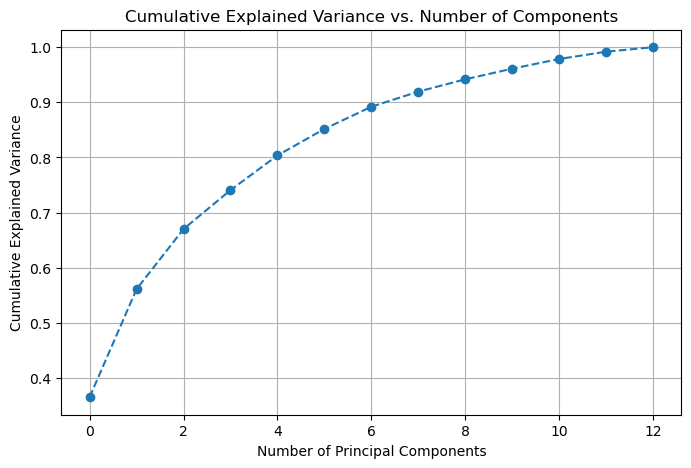

In [28]:
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance vs. Number of Components')
plt.grid(True)
plt.show()

In [29]:
pca=PCA(n_components=10)
X_pca = pca.fit_transform(features)

In [30]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [32]:
kmeans=KMeans(n_clusters=3)
cluster=kmeans.fit(features)

In [33]:
np.unique(cluster.labels_)

array([0, 1, 2], dtype=int32)

In [34]:
df['Cluster'] = cluster.labels_
df[df.Cluster==0]

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline,Cluster
59,2,12.37,0.94,1.68875,10.75,88.0,1.98,0.57,0.28,0.42,1.95,1.05,1.82,520,0
60,2,12.33,1.10,2.28000,16.00,101.0,2.05,1.09,0.63,0.41,3.27,1.25,1.67,680,0
62,2,13.67,1.25,1.92000,18.00,94.0,2.10,1.79,0.32,0.73,3.80,1.23,2.46,630,0
63,2,12.37,1.13,2.16000,19.00,87.0,3.50,3.10,0.19,1.87,4.45,1.22,2.87,420,0
64,2,12.17,1.45,2.53000,19.00,104.0,1.89,1.75,0.45,1.03,2.95,1.45,2.23,355,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,2,12.07,2.16,2.17000,21.00,85.0,2.60,2.65,0.37,1.35,2.76,0.86,3.28,378,0
126,2,12.43,1.53,2.29000,21.50,86.0,2.74,3.15,0.39,1.77,3.94,0.69,2.84,352,0
127,2,11.79,2.13,2.78000,27.95,92.0,2.13,2.24,0.58,1.76,3.00,0.97,2.44,466,0
128,2,12.37,1.63,2.30000,24.50,88.0,2.22,2.45,0.40,1.90,2.12,0.89,2.78,342,0


In [35]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(features)

<Figure size 1000x800 with 0 Axes>

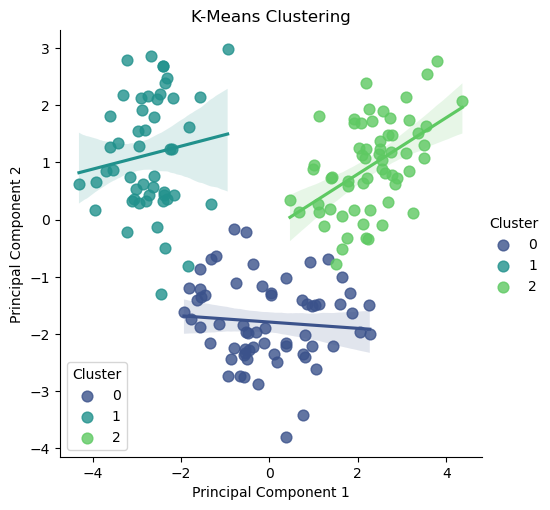

In [36]:
#  DataFrame with PCA results and cluster labels
pca_df = pd.DataFrame(data = X_pca, columns = ['principal component 1', 'principal component 2'])
pca_df['Cluster'] = cluster.labels_
plt.figure(figsize=(10,8))
sns.lmplot(data=pca_df, x='principal component 1', y='principal component 2', hue='Cluster', palette='viridis', scatter_kws={'s': 60})
plt.title('K-Means Clustering')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

In [37]:
silhouette_score(features,cluster.labels_)

0.2854626783251893

In [38]:
kmeans=KMeans(n_clusters=3, random_state=100)
cluster_pca=kmeans.fit(X_pca)

In [41]:
np.unique(cluster.labels_)

array([0, 1, 2], dtype=int32)

In [42]:
df['Cluster_PCA']=cluster_pca.labels_

In [43]:
df[df.Cluster_PCA==1]

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline,Cluster,Cluster_PCA
0,1,14.23,1.71,2.43000,15.60,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,2,1
1,1,13.20,1.78,2.14000,11.20,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,2,1
2,1,13.16,2.36,2.67000,18.60,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,2,1
3,1,14.37,1.95,2.50000,16.80,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,2,1
4,1,13.24,2.59,2.87000,21.00,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,2,12.99,1.67,2.60000,27.95,135.5,3.30,2.89,0.21,1.96,3.35,1.31,3.50,985,2,1
78,2,12.33,0.99,1.95000,14.80,135.5,1.90,1.85,0.35,2.76,3.40,1.06,2.31,750,0,1
95,2,12.47,1.52,2.20000,19.00,135.5,2.50,2.27,0.32,3.00,2.60,1.16,2.63,937,2,1
98,2,12.37,1.07,2.10000,18.50,88.0,3.52,3.75,0.24,1.95,4.50,1.04,2.77,660,0,1


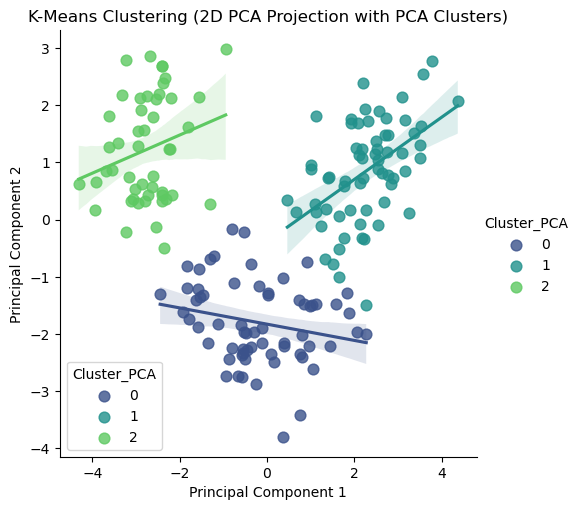

In [44]:
# DataFrame with PCA results and cluster labels from PCA clustering
pca_df_pca_clusters = pd.DataFrame(data = X_pca, columns = ['principal component 1', 'principal component 2'])
pca_df_pca_clusters['Cluster_PCA'] = cluster_pca.labels_

sns.lmplot(data=pca_df_pca_clusters, x='principal component 1', y='principal component 2', hue='Cluster_PCA', palette='viridis', scatter_kws={'s': 60})
plt.title('K-Means Clustering (2D PCA Projection with PCA Clusters)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster_PCA')
plt.show()

In [45]:
silhouette_pca = silhouette_score(X_pca, cluster_pca.labels_)
silhouette_pca

0.5619178058700298

##### Compare the clustering results obtained from the original dataset and PCA-transformed data.

##### Discuss any similarities or differences observed in the clustering results.

##### Reflect on the impact of dimensionality reduction on clustering performance.

##### Analyze the trade-offs between using PCA and clustering directly on the original dataset.

##### Summarize the key findings and insights from the assignment.

Dimensionality reduction via PCA enhanced cluster compactness and separation, PCA preserved the natural groupings in the wine dataset, PCA reduced noise and improved efficiency but may lose some information, Both original and PCA-based clustering showed similar cluster formations.The silhouette score improved slightly, confirming that PCA helped in forming more cohesive and well-separated clusters.

##### Discuss the practical implications of using PCA and clustering in data analysis.

##### Provide recommendations for when to use each technique based on the analysis conducted.